### Salary EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

In [ ]:
# Load data into memory
df = pd.read_csv('data/adult11.csv')
print(df)


       age     workclass  fnlwgt     education  education-num  \
0       25       Private  226802          11th              7   
1       38       Private   89814       HS-grad              9   
2       28     Local-gov  336951    Assoc-acdm             12   
3       44       Private  160323  Some-college             10   
4       18             ?  103497  Some-college             10   
...    ...           ...     ...           ...            ...   
48837   27       Private  257302    Assoc-acdm             12   
48838   40       Private  154374       HS-grad              9   
48839   58       Private  151910       HS-grad              9   
48840   22       Private  201490       HS-grad              9   
48841   52  Self-emp-inc  287927       HS-grad              9   

           marital-status         occupation relationship   race  gender  \
0           Never-married  Machine-op-inspct    Own-child  Black    Male   
1      Married-civ-spouse    Farming-fishing      Husband  White   

In [7]:
# Initial check
rows, cols = df.shape

print(f'Rows: {rows}')
print(f'Cols: {cols}')

Rows: 48842
Cols: 15


In [ ]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,salary
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [10]:
df.tail()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,salary
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K
48841,52,Self-emp-inc,287927,HS-grad,9,Married-civ-spouse,Exec-managerial,Wife,White,Female,15024,0,40,United-States,>50K


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             48842 non-null  int64
 1   workclass       48842 non-null  str  
 2   fnlwgt          48842 non-null  int64
 3   education       48842 non-null  str  
 4   education-num   48842 non-null  int64
 5   marital-status  48842 non-null  str  
 6   occupation      48842 non-null  str  
 7   relationship    48842 non-null  str  
 8   race            48842 non-null  str  
 9   gender          48842 non-null  str  
 10  capital-gain    48842 non-null  int64
 11  capital-loss    48842 non-null  int64
 12  hours-per-week  48842 non-null  int64
 13  native-country  48842 non-null  str  
 14  salary          48842 non-null  str  
dtypes: int64(6), str(9)
memory usage: 5.6 MB


In [12]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [15]:
print(f'Duplicate Rows: {df.duplicated().sum()}')
df = df.drop_duplicates()

Duplicate Rows: 52


In [16]:
print(f'Duplicate Rows: {df.duplicated().sum()}')

Duplicate Rows: 0


In [14]:
print(f'Missing Values\n', df.isnull().sum())

Missing Values
 age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
gender            0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
salary            0
dtype: int64


### Taking a closer look at education and finalweight

- goal: is to observe the amount of the population that of observed in each education level

In [17]:
df['education'].value_counts()

education
HS-grad         15770
Some-college    10863
Bachelors        8013
Masters          2656
Assoc-voc        2060
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           954
Prof-school       834
9th               756
12th              655
Doctorate         594
5th-6th           507
1st-4th           245
Preschool          81
Name: count, dtype: int64

In [18]:
subset = df.groupby('education')['fnlwgt'].sum().reset_index()

subset

,education,fnlwgt
0,10th,272983724
1,11th,353525318
2,12th,129251530
3,1st-4th,57658082
4,5th-6th,116627557
5,7th-8th,179115747
6,9th,150449180
7,Assoc-acdm,310113821
8,Assoc-voc,369606571
9,Bachelors,1509621616


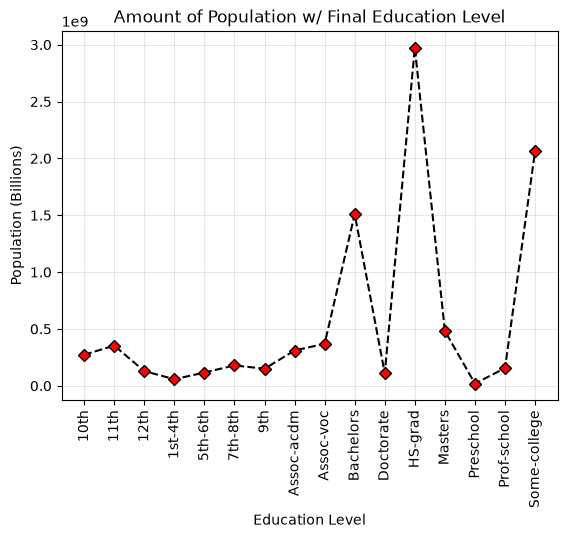

In [32]:
plt.plot(
    subset['education'],
    subset['fnlwgt'],
    color='black',
    marker='D',
    markerfacecolor='red',
    linestyle='--'
    )
plt.title('Amount of Population w/ Final Education Level')
plt.xlabel('Education Level')
plt.ylabel('Population (Billions)')
plt.xticks(rotation=90)
plt.grid(alpha=0.3)
plt.show()

In [35]:
# subset of median age per education group
subset1 = df.groupby('education')['age'].median().reset_index()
subset1

,education,age
0,10th,35.0
1,11th,28.0
2,12th,29.0
3,1st-4th,46.0
4,5th-6th,43.0
5,7th-8th,51.0
6,9th,39.0
7,Assoc-acdm,37.0
8,Assoc-voc,37.0
9,Bachelors,37.0


In [ ]:
education_order = ['Preschool', '1st-4th', '5th-6th', '7th-8th', '9th', '10th', '11th', '12th', 'HS-grad', 'Some-college', 'Assoc-acdm', 'Assoc-voc', 'Bachelors', 'Masters', 'Doctorate', 'Prof-school']

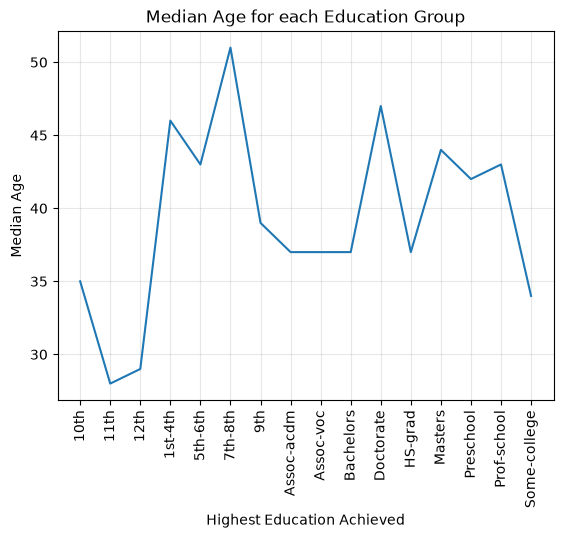

In [37]:
fig, axes = plt.subplots()

axes.plot(subset1['education'], subset1['age'])
axes.set_title('Median Age for each Education Group')
axes.set_xlabel('Highest Education Achieved')
axes.set_ylabel('Median Age')
axes.tick_params('x', rotation=90)

plt.grid(alpha=0.3)
plt.show()